In [36]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import re
pd.set_option("display.max_rows", 400)

In [37]:
df = pd.read_csv('results.csv')

In [38]:
metrics    = list(df.columns)[1:df.columns.get_loc('xp')] # +1 as we dont want the run name
attributes = list(df.columns)[df.columns.get_loc('xp')+2:][:21] # +1 as we dont want the run name

In [39]:
# get the metrics for each run (mean, min,max) across folds

aggs = { 'xp':['first'] ,'fold':['count']} # inital omes

for metric in metrics:
    aggs[metric] = ['mean','std','min','max']

results = df.groupby(attributes).agg(aggs).reset_index()

results.head(2)

feature_file paitent_limit            np_bags_dir bag_size  \
                                                                 
0  data/brca.csv          1000  data/bags_np/bag_150/       64   
1  data/brca.csv          1000  data/bags_np/bag_150/      128   

  resample_small_bags static_bags no_concepts batch_size epochs learning_rate  \
                                                                                
0                True       False       False         16     10         0.010   
1                True       False       False          8     10         0.001   

   ... RNA_Bio_ter_class2_recall           RNA_Bio_ter_class2_f1            \
   ...                       min       max                  mean       std   
0  ...                       0.0  0.166667                 0.025  0.079057   
1  ...                       0.0  0.000000                 0.000  0.000000   

             RNA_Bio_ter_class2_support                      
   min   max                       mean       std  min  max  
0  0.0  0.25                        3.2  1.813529  1.0  6.0  
1  0.0  0.00                        3.2  1.813529  1.0  6.0  

[2 rows x 283 columns]

In [40]:
# use the results to give each run a unique id ['xp_id'] based on all folkds with the same hyperparameters
idx_cols = attributes.copy()
for col in attributes:
    if results[col].nunique() == 1:
        results = results.drop(col, axis=1)
        idx_cols.remove(col)
results = results.set_index(idx_cols)

xp_names = results[[('xp','first')]]

xp_names.columns = ['xp_id']
merge_features = list(xp_names.index.names)
xp_names = xp_names.reset_index()

df = pd.merge(df,xp_names,left_on=merge_features,right_on=merge_features,how='left')

df.head(2)

/var/folders/g3/_9x8pwg55flb2rz_2ksl59f40000gn/T/ipykernel_33933/964531664.py:5: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  results = results.drop(col, axis=1)


,fold,task_c_index,Stage_accuracy,Stage_macro_precision,Stage_macro_recall,Stage_macro_f1,Stage_weighted_precision,Stage_weighted_recall,Stage_weighted_f1,Stage_auc_ovo,...,Stage_classconfusion_support,Age_classconfusion_precision,Age_classconfusion_recall,Age_classconfusion_f1,Age_classconfusion_support,RNA_Bio_ter_classconfusion_precision,RNA_Bio_ter_classconfusion_recall,RNA_Bio_ter_classconfusion_f1,RNA_Bio_ter_classconfusion_support,xp_id
0,fold_0,0.644803,0.486486,0.386273,0.278471,0.278090,0.452439,0.486486,0.458152,0.582047,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baseline_1781214199
1,fold_1,0.717808,0.486486,0.340012,0.305313,0.307935,0.457268,0.486486,0.455098,0.616603,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baseline_1781214199


In [41]:

def run_plot(ax,df,xps,metric,y_min,y_max,chance_level,labels=None):

    ''' Produce boxplot across all folds for specified metric across a list of experiments'''

    colors = [
    "#A6CEE3",  
    "#FDBF6F", 
    "#B2DF8A",  
    "#FB9A99",  
    "#CAB2D6",  
    "#E6B8A2", 
    "#FFED6F",  
    "#B3E2CD",  
    "#FDB5A6",  
    "#CFCFCF", 
    "#D2A6FF",  
    "#ACE7FF",  
    "#FFF1BA",  
    "#FCB9B2",  
    "#B5D8B8",  
    "#FFD8B1",  
    "#FBEAFF",  
    "#D5E8D4",  
    "#FFE0AC",  
    "#D1C4E9",  

    ]

    y_range = y_max-y_min
    mean_label = y_max - (0.17*y_range)
    n_label = y_max - (0.22*y_range)
    legend_label = 0.99


    data =df[df['xp_id'].isin(xps)][['xp_id','xp','run','fold',metric]].set_index(['xp_id','xp','run','fold']).unstack(level=0)

    data.columns = [x[1] for x in data.columns]


    for n,xp in enumerate(xps):

        vals = data[xp].values
        vals = vals[~np.isnan(vals)]
    
        
        boxplot = ax.boxplot(vals, positions=[n+1]
        , widths=0.6
        , patch_artist=True
        , medianprops=dict(color="black", linewidth=2)
        , boxprops=dict(color="black", linewidth=1, facecolor=colors[n%len(colors)])
        , showfliers=False
        )


        jitter = np.random.normal(0,0.05,len(vals))
        ax.scatter(np.ones(len(vals))*(n+1)+jitter,vals
        ,alpha=0.7
        ,edgecolor="black"
        ,facecolor=colors[n%len(colors)]
        ,linewidth=1
        ,s=20
        ,zorder=10
        )

        ax.text(n+1,mean_label,f"{vals.mean():.2f}±{vals.std():.2f}",ha="center",va="bottom")
        ax.text(n+1,n_label,f"n={vals.shape[0]}",ha="center",va="bottom")

        rect = Rectangle(
        (n+1-0.42, n_label),   # (x, y) bottom-left corner
        0.85,          # width
        0.11*(y_range),          # height
        fill=True,    # no fill (outline only)
        color='#D3D3D3'
        )
        ax.add_patch(rect)
   
   

    # # plot the raw


    ax.set_ylim([y_min,y_max])

    ax.axhline(chance_level,color="red",linestyle="--",label="Chance level")
    ax.axhline(0,color="black",linestyle="-",linewidth=2,label="Median")


    ax.set_title(f"{metric}",loc="left")

    ax.set_xticks(range(1,n+2))

    if labels is not None:
        ax.set_xticklabels(labels)
    else:
        labels_no_ts =[re.split(r'_\d+', x)[0] for x in xps]
        ax.set_xticklabels([x.replace('_','\n') for x in labels_no_ts])
    
    ax.yaxis.grid(True,color="black",alpha=0.1,linestyle="--",linewidth=0.5)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles,
    labels,

        bbox_to_anchor=(0.64, legend_label),
        ncol=len(handles),
        borderaxespad=0.,
        frameon=True
    )





In [34]:
def xp_summary(results,xps,metrics=['task_c_index'],xps_as_rows=True,labels=None):


    '''Produce a table of metrics per experiment'''


    summary_table = results[results[('xp','first')].isin(xps)]


    summary_table = summary_table.reset_index(drop=True).set_index(('xp','first'))

    cols = [x for x in summary_table.columns if x[0] in ['fold']+metrics]

    summary_table = summary_table[cols].copy()

    # create a col for table
    for metric in metrics:
        summary_table[(metric,'str')] = summary_table[(metric,'mean')].round(2).astype(str) + " ± " + summary_table[(metric,'std')].round(2).astype(str)

    summary_table.sort_index(inplace=True,axis=1)

    summary_table = summary_table[[('fold','count')]+[(metric,'str') for metric in metrics]]

    summary_table.columns = ['n'] + [x[0] for x in summary_table.columns[1:]]

    summary_table = summary_table.loc[xps] # reorder as provided

    if labels is not None:
        summary_table.index = labels
    else:
        labels_no_ts =[re.split(r'_\d+', x)[0] for x in summary_table.index]
        summary_table.index = labels_no_ts

    if xps_as_rows:

        return summary_table
    else:
        return summary_table.T



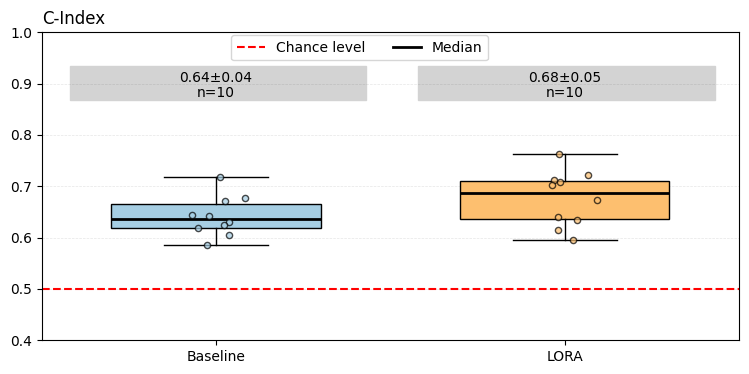

,n,task_c_index
baseline,10,0.64 ± 0.04
ft_lora_e7,10,0.68 ± 0.05


In [ ]:
xps = [
'baseline_1781214199'
,'ft_lora_e7_1782331269'
]

labels = ['Baseline'
,'LORA'
]


fig, ax = plt.subplots(1,1,figsize=(9,4))
run_plot(ax,df,xps,'task_c_index',0.4,1,0.5,labels)
ax.set_title('C-Index',loc='left')
plt.savefig('blackbox_plot.pdf', bbox_inches="tight")
plt.show()

xp_summary(results,xps)